In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

In [62]:
!pip install emoji

In [63]:
import emoji

In [64]:
!pip install autocorrect

In [65]:
import autocorrect

In [66]:
data=pd.read_csv('data.csv')
data.head()

,Reviewer Name,Review Title,Place of Review,Up Votes,Down Votes,Month,Review text,Ratings
0,Kamal Suresh,Nice product,"Certified Buyer, Chirakkal",889.0,64.0,Feb 2021,"Nice product, good quality, but price is now r...",4
1,Flipkart Customer,Don't waste your money,"Certified Buyer, Hyderabad",109.0,6.0,Feb 2021,They didn't supplied Yonex Mavis 350. Outside ...,1
2,A. S. Raja Srinivasan,Did not meet expectations,"Certified Buyer, Dharmapuri",42.0,3.0,Apr 2021,Worst product. Damaged shuttlecocks packed in ...,1
3,Suresh Narayanasamy,Fair,"Certified Buyer, Chennai",25.0,1.0,NaN,"Quite O. K. , but nowadays the quality of the...",3
4,ASHIK P A,Over priced,NaN,147.0,24.0,Apr 2016,Over pricedJust â?¹620 ..from retailer.I didn'...,1


In [67]:
data = data.dropna(subset=['Review text'])

In [68]:
data.isnull().sum()

Reviewer Name        2
Review Title         2
Place of Review     42
Up Votes             2
Down Votes           2
Month              457
Review text          0
Ratings              0
dtype: int64

# Text Preprocessing

In [69]:
R=data['Review text']
R.head()

0    Nice product, good quality, but price is now r...
1    They didn't supplied Yonex Mavis 350. Outside ...
2    Worst product. Damaged shuttlecocks packed in ...
3    Quite O. K. , but nowadays  the quality of the...
4    Over pricedJust â?¹620 ..from retailer.I didn'...
Name: Review text, dtype: object

## Lowercase convert

In [70]:
R=R.str.lower()

## remove punctuations

In [71]:
import re
R=R.str.replace(r'[^a-z\s]','',regex=True)
R

0       nice product good quality but price is now ris...
1       they didnt supplied yonex mavis  outside cover...
2       worst product damaged shuttlecocks packed in n...
3       quite o k  but nowadays  the quality of the co...
4       over pricedjust  from retaileri didnt understa...
                              ...                        
8505    delivered before time but price is high from m...
8506    up to the mark but same is available in market...
8507                         nice delivery speedread more
8508    no complaints about the item  its the best one...
8509    not sure why we have charged for this product ...
Name: Review text, Length: 8510, dtype: object

## Tokenization

In [72]:
token=R.str.split()
print(token.head())

0    [nice, product, good, quality, but, price, is,...
1    [they, didnt, supplied, yonex, mavis, outside,...
2    [worst, product, damaged, shuttlecocks, packed...
3    [quite, o, k, but, nowadays, the, quality, of,...
4    [over, pricedjust, from, retaileri, didnt, und...
Name: Review text, dtype: object


## Word Tokenization

In [73]:
!pip uninstall nltk -y
!pip install --upgrade nltk

Found existing installation: nltk 3.9.2
Uninstalling nltk-3.9.2:
  Successfully uninstalled nltk-3.9.2
  Using cached nltk-3.9.2-py3-none-any.whl.metadata (3.2 kB)
Using cached nltk-3.9.2-py3-none-any.whl (1.5 MB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
preprocessing 0.1.13 requires nltk==3.2.4, but you have nltk 3.9.2 which is incompatible.


In [74]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Subramanyam\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Subramanyam\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [75]:
token=word_tokenize(R.iloc[0])
print(token)

['nice', 'product', 'good', 'quality', 'but', 'price', 'is', 'now', 'rising', 'which', 'is', 'a', 'bad', 'sign', 'was', 'an', 'affordable', 'price', 'especially', 'when', 'we', 'play', 'everyday', 'so', 'kindly', 'help', 'us', 'out', 'in', 'terms', 'of', 'the', 'price', 'thank', 'youread', 'more']


## StopWords

In [76]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words=set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Subramanyam\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [77]:
print(stop_words)

{'should', 'on', 'only', 'shan', "haven't", 'more', 'most', 'its', 'you', 'until', "shan't", 'wasn', 'above', "that'll", 'couldn', "didn't", 'll', 'aren', "aren't", "he's", 'those', 'your', 'had', 'her', 'and', 'by', 'themselves', "i'd", 'each', 'below', 'too', 'doesn', 'ours', "we're", 'when', "they'll", 'will', 'these', "i'm", 'if', 'now', 'does', "she'd", 'so', 'there', 'further', 'they', 'again', "mightn't", 'over', "doesn't", 'ain', 'is', 'here', 'have', 'don', 'nor', 'doing', 'his', "it'll", 'me', 'be', 'to', 'do', "we've", 'off', 'any', 'm', "shouldn't", 'about', "they've", 'wouldn', 'needn', 'yours', 'was', 'once', 'herself', "he'll", 'he', 'been', 'between', "wouldn't", 'mightn', "we'd", "they're", "you've", 're', 'in', 'd', 'she', "needn't", 'didn', 's', 'it', "she'll", "you're", 'can', "it's", 'out', 'won', 'how', 'this', 'of', 't', 'an', 'or', 'down', "should've", 'with', 'no', 'why', "isn't", "i've", "weren't", 'then', 'such', 'ourselves', 'having', 'under', 'has', 'yourse

In [78]:
filtered_words=[word for word in token if word not in stop_words]
print(filtered_words)

['nice', 'product', 'good', 'quality', 'price', 'rising', 'bad', 'sign', 'affordable', 'price', 'especially', 'play', 'everyday', 'kindly', 'help', 'us', 'terms', 'price', 'thank', 'youread']


# 2,Text Normalization

In [79]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Subramanyam\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Subramanyam\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [80]:
lemmatizer=WordNetLemmatizer()
lemmatized_words=[lemmatizer.lemmatize(word) for word in filtered_words]
print(lemmatized_words)

['nice', 'product', 'good', 'quality', 'price', 'rising', 'bad', 'sign', 'affordable', 'price', 'especially', 'play', 'everyday', 'kindly', 'help', 'u', 'term', 'price', 'thank', 'youread']


In [81]:
from nltk.corpus import wordnet
lemmatized_words=[lemmatizer.lemmatize(word,pos='v') for word in filtered_words]
print(lemmatized_words)

['nice', 'product', 'good', 'quality', 'price', 'rise', 'bad', 'sign', 'affordable', 'price', 'especially', 'play', 'everyday', 'kindly', 'help', 'us', 'term', 'price', 'thank', 'youread']


# 3. Numerical Feature Extraction

In [82]:
from sklearn.feature_extraction.text import CountVectorizer
vect=CountVectorizer(binary=True)
bag=vect.fit_transform(lemmatized_words)
print('Vocabulary:',vect.get_feature_names_out())
print('Bow matrix:\n',bag.toarray())

Vocabulary: ['affordable' 'bad' 'especially' 'everyday' 'good' 'help' 'kindly' 'nice'
 'play' 'price' 'product' 'quality' 'rise' 'sign' 'term' 'thank' 'us'
 'youread']
Bow matrix:
 [[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]]


In [83]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
analyzer = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Subramanyam\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [84]:
data['Review text'] = data['Review text'].fillna('').astype(str)

In [85]:
def polarity(n):
    return analyzer.polarity_scores(n)['compound']

In [86]:
data['Emotion'] = data['Review text'].apply(polarity)

In [87]:
data['Emotion']

0       0.9267
1      -0.4767
2      -0.9146
3       0.9566
4       0.2500
         ...  
8505    0.0000
8506    0.0000
8507    0.4215
8508    0.5023
8509   -0.8436
Name: Emotion, Length: 8510, dtype: float64

In [88]:
def sentiment(n):
    if n <= 0.3:
        return 'Negative'
    else:
        return 'Positive'

In [89]:
data['Emotion'] = data['Emotion'].apply(sentiment)

<Axes: xlabel='Emotion'>

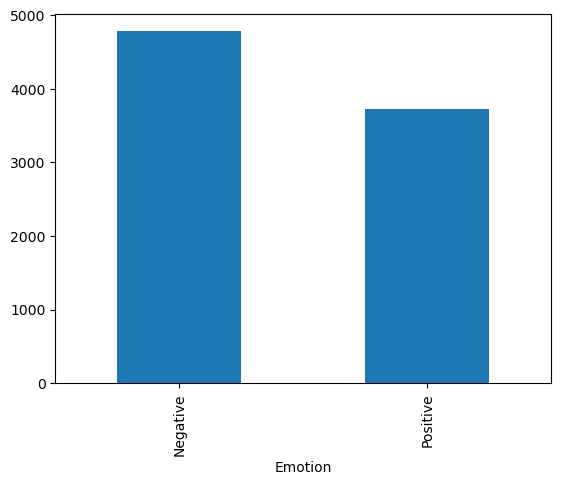

In [90]:
data['Emotion'].value_counts().plot(kind = 'bar')

In [91]:

df = pd.concat([data['Review text'],data['Emotion']],axis=1)

In [105]:
df

,Review text,Emotion
0,"Nice product, good quality, but price is now r...",Positive
1,They didn't supplied Yonex Mavis 350. Outside ...,Negative
2,Worst product. Damaged shuttlecocks packed in ...,Negative
3,"Quite O. K. , but nowadays the quality of the...",Positive
4,Over pricedJust â?¹620 ..from retailer.I didn'...,Negative
...,...,...
8505,Delivered before time but price is high from m...,Negative
8506,up to the mark but same is available in market...,Negative
8507,Nice delivery speedREAD MORE,Positive
8508,No complaints about the item . Its the best on...,Positive


In [106]:
df['Emotion'].value_counts()

Emotion
Negative    4784
Positive    3726
Name: count, dtype: int64

In [107]:
X=df['Review text']
y=df['Emotion']

In [108]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [109]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
pipe=Pipeline([('Vectorization',CountVectorizer(stop_words='english')),
              ("Estimator",MultinomialNB(alpha=3))])

In [110]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('Vectorization', CountVectorizer(stop_words='english')),
                ('Estimator', MultinomialNB(alpha=3))])

In [111]:
y_pred = pipe.predict(X_test)

In [112]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8742655699177438

In [113]:
from sklearn.metrics import f1_score
f1_score(y_test, y_pred, average='weighted')

0.874594038846542

In [114]:
pipe.predict(['Waste Product'])

array(['Negative'], dtype='<U8')

In [ ]:
# Save model
import pickle
pickle.dump(pipe, "sentiment_flipkart.pkl")

['sentiment_flipkart.pkl']

In [116]:
import os
os.getcwd()

'C:\\Users\\Subramanyam\\Desktop\\internship'